In [2]:
from tool2 import *
import torch
device = 'cuda' if torch.cuda.is_available() else 'mps'  # 'cpu
print(device)

mps


In [5]:
# 무작위 H, s 로 차원만 점검
B, N, h_enc, h_dec = 2, 7, 16, 12
attn = BahdanauAttention(h_dec, h_enc, attn_dim=8).to(device)
H = torch.randn(B, N, h_enc, device=device)
s = torch.randn(B, h_dec, device=device)
c, a = attn(s, H); 

print(c.shape, a.shape)

torch.Size([2, 16]) torch.Size([2, 7])


In [10]:
a.sum(dim=1)
a[0]

tensor([0.1187, 0.1117, 0.1746, 0.1306, 0.1556, 0.1366, 0.1722],
       device='mps:0', grad_fn=<SelectBackward0>)

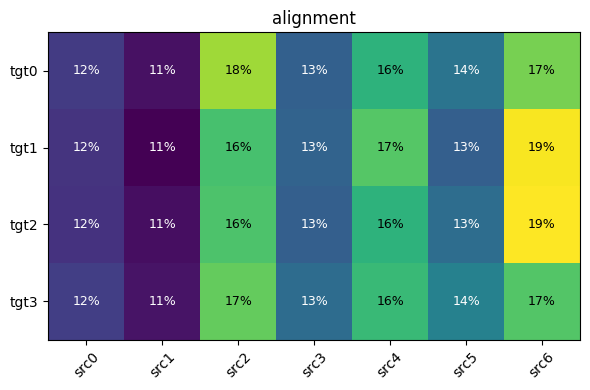

In [11]:
# 4 개 디코더 step 의 alpha 를 모아 heatmap 으로
alpha = torch.stack([attn(torch.randn(1, h_dec, device=device), H[:1])[1].squeeze(0) for _ in range(4)])
show_alignment(alpha.detach().cpu().numpy(), [f'src{i}' for i in range(N)], [f'tgt{i}' for i in range(4)])